In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Статпрак/forest_dataset.csv')

In [21]:
labels = data[data.columns[-1]].values
feature_matrix = data[data.columns[:-1]].values

In [22]:
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(feature_matrix, labels, test_size=0.2, random_state=42)

# Homework

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


Train the `KNeighborsClassifier` on the dataset.

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)

KNeighborsClassifier()

Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [45]:
from sklearn.model_selection import GridSearchCV
params = { 'n_neighbors': range(1,11),
            'metric' : ['manhattan', 'euclidean'],
            'weights' : ['uniform', 'distance']
          }

clf_grid = GridSearchCV(KNeighborsClassifier(), params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['manhattan', 'euclidean'],
                         'n_neighbors': range(1, 11),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

Let's output the best parameters

In [26]:
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}

Using the optimal number of neighbors found, calculate the probabilities of belonging to classes for the test sample (`.predict_proba`).

In [48]:
optimal_clf = clf_grid.best_estimator_
pred_prob = optimal_clf.predict_proba(test_feature_matrix)
y_pred = optimal_clf.predict(test_feature_matrix)

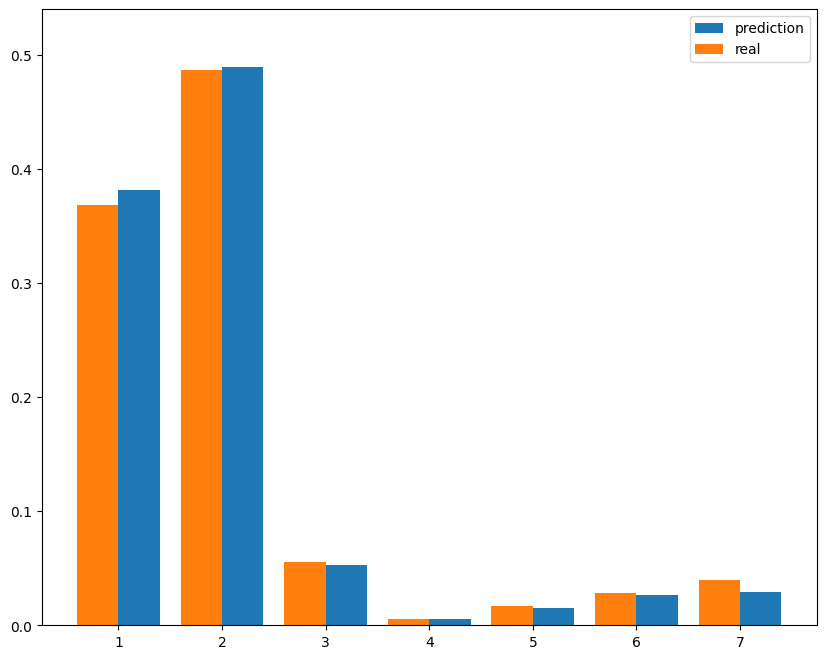

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

## Conclusion

What is the quality of the model on the test sample? Compare it with the quality of logistic regression. Which model is better? Why? What are the pros and cons of the k Nearest Neighbors method? Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

In [53]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

knn_accuracy = accuracy_score(test_labels, y_pred)
print(f"Точность лучшей модели kNN: {knn_accuracy:.4f}")

log_reg_accuracy = 0.642
print(f"Точность логистической регрессии: {log_reg_accuracy:.4f}")

if knn_accuracy > log_reg_accuracy:
    print("\nМодель kNN показала лучший результат.")
else:
    print("\nМодель логистической регрессии показала лучший результат.")

Точность лучшей модели kNN: 0.7845
Точность логистической регрессии: 0.6420

Модель kNN показала лучший результат.


AUC-ROC для модели kNN: 0.9063


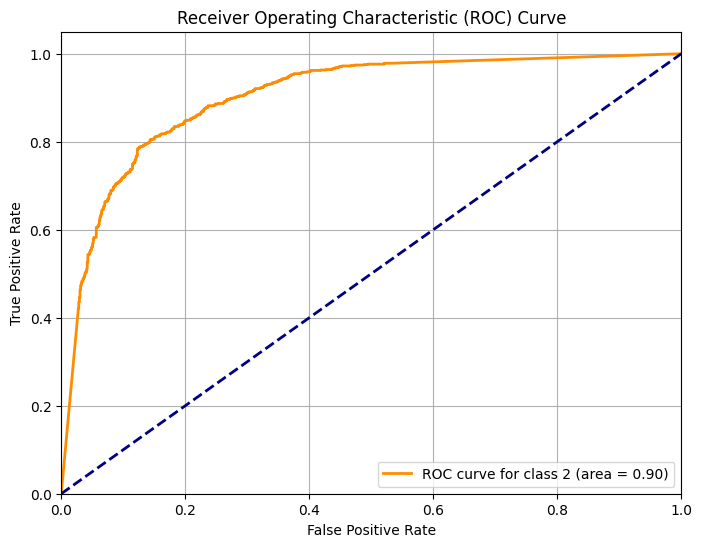

In [54]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

auc_roc = roc_auc_score(test_labels, pred_prob, multi_class='ovr')
print(f"AUC-ROC для модели kNN: {auc_roc:.4f}")

from sklearn.preprocessing import label_binarize

y_bin = label_binarize(test_labels, classes=list(range(1, 8)))
n_classes = y_bin.shape[1]

class_index_to_plot = 1

fpr, tpr, _ = roc_curve(y_bin[:, class_index_to_plot], pred_prob[:, class_index_to_plot])
roc_auc_single_class = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve for class 2 (area = {roc_auc_single_class:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

Метод k-ближайших соседей требует внимательного подбора гиперпараметров, так как производительность модели сильно зависит от выбора k (количества соседей). Для автоматизации этого процесса целесообразно применять GridSearch. К недостаткам можно отнести то, что для предсказания требуется хранить в памяти весь обучающий набор данных. Это делает kNN неэффективным и медленным при работе с очень большими объемами данных. Среди преимуществ стоит отметить, что kNN хорошо подходит для динамических наборов данных, которые часто пополняются. При добавлении нового объекта нет необходимости заново обучать всю модель — достаточно просто добавить его к существующим данным.